In [1]:
import pandas as pd

data = pd.read_csv("selected_latency.csv")
data = data.rename(columns={
    "Model": "model",
    "latency(s)": "latency",
    "memory(m)": "memory",
    "cpu time(ms)": "cpu_time",
    "gpu time(ms)": "gpu_time",
    "normalised_throughput" : "throughput_final",
    "normalised_memory": "memory_final",
})
data = data.dropna(subset=["model"]).fillna(0)

method_names = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
model_names = ["ResNet32", "ResNet50", "ResNet101", "ResNet152", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]

def rename_models(data):
    old = ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"]
    new = ["ResNet32", "ResNet110", "ResNet164", "ResNet101-1k", "GPT", "Swin", "BERT", "ViT", "DeiT", "UNet", "BART", "YOSO"]
    for o, n in zip(old, new):
        data.loc[data.model == o, "model"] = n
        
def rename_methods(data):
    old = ["base", "manual", "reversify", "checkpoint"]
    new = ["Original", "SOTA-Revs", "ReverSyn", "Checkpoint"]
    for o, n in zip(old, new):
        data.loc[data.method == o, "method"] = n
    
for old, new in zip(
    ["base", "manual", "reversify", "checkpoint"], 
    method_names
):
    data.loc[data.method == old, "method"] = new
    
for old, new in zip(
    ["resnet32", "resnet110", "resnet164", "resnet101-1k", "gpt", "swin", "bert", "vit", "deit", "unet", "bart", "yoso"],
    model_names
):
    data.loc[data.model == old, "model"] = new
    
latency = data
print(latency)

    Unnamed: 0      model      method   latency  memory  cpu_time  gpu_time  \
0            0   ResNet32    Original  0.014868    1552    35.949    18.640   
1            1   ResNet32   SOTA-Revs  0.027730    1500    76.855    34.582   
2            2   ResNet32    ReverSyn  0.015056    1470    35.930    18.674   
3            3   ResNet32  Checkpoint  0.034049    1500    99.575    41.028   
4            4   ResNet50    Original  0.000000    7481     0.000     0.000   
5            5   ResNet50   SOTA-Revs  0.000000    5378     0.000     0.000   
6            6   ResNet50    ReverSyn  0.000000    5136     0.000     0.000   
7            7   ResNet50  Checkpoint  0.000000    5578     0.000     0.000   
8            8  ResNet101    Original  0.000000    7563     0.000     0.000   
9            9  ResNet101   SOTA-Revs  0.000000    4427     0.000     0.000   
10          10  ResNet101    ReverSyn  0.000000    4089     0.000     0.000   
11          11  ResNet101  Checkpoint  0.000000    5

In [2]:
import warnings

warnings.filterwarnings("ignore")

def normalize(data):
    latency_normalized = []

    for model in model_names:
        subtable = data[data.model == model]
        baseline = subtable[subtable.method == "ReverSyn"].latency.item()
        for method in method_names:
            row = subtable[subtable.method == method]
            row["ratio"] = row.latency.item() / baseline
            latency_normalized.append(row)

    return pd.concat(latency_normalized)

#latency = normalize(latency)

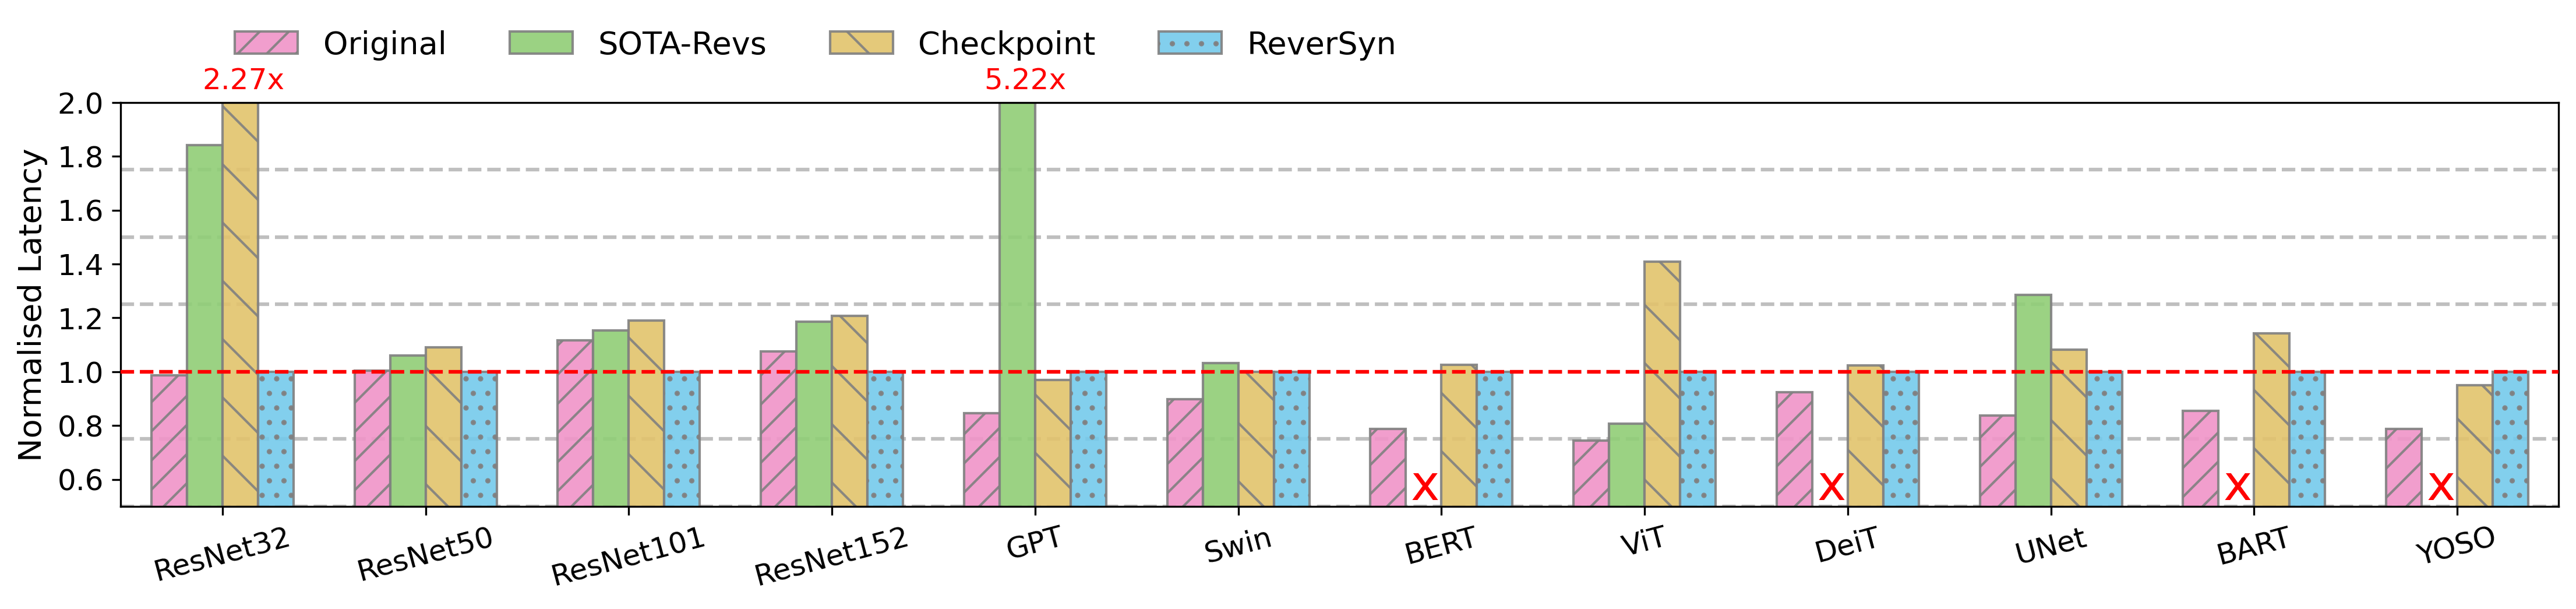

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 300

colors = ["#FF85CA", "#8ADD67", "#F6CC58", "#60D3FF"]
sns.set_palette(colors)

hatches = ["//", "", "\\", "..", "--", "oo"]

plt.rcParams["figure.figsize"] = (18, 3)
ax = sns.barplot(latency, x="model", y="normalised_latency", hue="method", hue_order=["Original", "SOTA-Revs", "Checkpoint", "ReverSyn"], edgecolor="black", alpha=0.9, width=0.7)
ax.axhline(y=1.0, color='r', linestyle='--', zorder=11)
plt.xlabel(None)
plt.ylabel("Normalised Latency", fontsize=13)
legend = plt.legend(loc="upper center", bbox_to_anchor=(0.285, 1.25), ncols=4, frameon=False, fontsize=13)

for patch, hatch in zip(legend.get_patches(), hatches):
    patch.set_hatch(hatch)
    patch.set_edgecolor("gray")

plt.xticks(rotation=15, fontsize=12)
#plt.xticks([])
plt.yticks(fontsize=12)
plt.ylim(0.5, 2.0)

for i, bar in enumerate(ax.patches):
    bar.set_hatch(hatches[i // len(model_names)])
    bar.set_edgecolor("gray")

# gpt manual
bar = ax.patches[0]
plt.text(bar.get_x()+0.25, 2.05, f'2.27x', color="red", fontsize=12)
bar = ax.patches[4]
plt.text(bar.get_x()+0.1, 2.05, f'{latency[(latency.model == "GPT") & (latency.method == "SOTA-Revs")].ratio.item():.2f}x', color="red", fontsize=12)

# manual
bar = ax.patches[6]
plt.text(bar.get_x() + 0.2, 0.525, "x", color="red", fontsize=20)
bar = ax.patches[8]
plt.text(bar.get_x() + 0.2, 0.525, "x", color="red", fontsize=20)
bar = ax.patches[10]
plt.text(bar.get_x() + 0.2, 0.525, "x", color="red", fontsize=20)
bar = ax.patches[11]
plt.text(bar.get_x() + 0.2, 0.525, "x", color="red", fontsize=20)
    
plt.subplots_adjust(wspace=1.0)

for y in [0.25 * i for i in range(2, 8)]:
    ax.axhline(y=y, color="gray", linestyle="--", zorder=0, alpha=0.5)

plt.savefig("latency-final.pdf", format="pdf", bbox_inches="tight", dpi=300, pad_inches=0.1)